In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pyreadr
import xarray as xr
import numpy as np

In [2]:
path_rds = "/Users/ud4/Documents/FACEMDS/Models/obs_data"

In [3]:
# Load the RDS file
# read mean annual
result = pyreadr.read_r(f'{path_rds}/OBS_ax.rds')
# Extract the object from the RDS file (result is a dictionary)
my_data = result[None]  # None is the key for the single R object in the file

# View the content
print(my_data)


            YEAR  DOY  CO2  PPT  PAR   AT   ST  VPD   SW NDEP  ... CL_herb  \
rownames                                                       ...           
1         1998.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
2         1999.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
3         2000.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
4         2001.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
5         2002.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
...          ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...     ...   
501       2009.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
511       2010.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
521       2011.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
531       2012.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
541       2013.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  .

In [4]:
# Load the RDS file
# read SE annual
result = pyreadr.read_r(f'{path_rds}/OBS_ase.rds')
# Extract the object from the RDS file (result is a dictionary)
my_data_se = result[None]  # None is the key for the single R object in the file




In [5]:
# Units

NPP_units = "gC m-2 y-1"
NUP_units = "gN m-2 y-1"

In [6]:
# dataframe of selected colms 
# relevant columns
rel_cols = ["YEAR", "co2", "site", "NPP", "NUP"]
# if you want to save the filtered dataframe to CSV
#my_data[rel_cols].to_csv("tmp/obs_a.csv")
df_obs_ax = my_data[rel_cols]
df_obs_ase = my_data_se[rel_cols]

In [7]:
# Filter the dataset to keep only rows where site is 'ORNL' or 'DUKE'
df_obs_ax_site = df_obs_ax[df_obs_ax['site'].isin(['ORNL', 'DUKE'])]
df_obs_ase_site = df_obs_ase[df_obs_ase['site'].isin(['ORNL', 'DUKE'])]

In [8]:
filter_co2 = df_obs_ase_site["co2"] == "AMB"
filter_site = df_obs_ase_site["site"] == "ORNL"
df_obs_ase_site[filter_co2][filter_site]

/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_42095/3136946482.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_obs_ase_site[filter_co2][filter_site]


,YEAR,co2,site,NPP,NUP
rownames,,,,,
1,1998.0,AMB,ORNL,24.968870,0.594035
2,1999.0,AMB,ORNL,67.395186,1.538964
3,2000.0,AMB,ORNL,44.160062,1.482355
4,2001.0,AMB,ORNL,80.133222,1.176157
5,2002.0,AMB,ORNL,35.139405,0.230964
6,2003.0,AMB,ORNL,54.003086,0.144952
7,2004.0,AMB,ORNL,26.859718,0.301901
8,2005.0,AMB,ORNL,67.838861,0.122202
9,2006.0,AMB,ORNL,27.430721,0.209311


In [51]:
# arrange data into dict!
dict_obs_ax = {}
sites_o= ("ORNL", "DUKE" )
sites_o= ( "ORNL", )

CO2_cases  = ("AMB", "ELE" )
dict_obs_ax = {}
dict_obs_ase = {} # standard error
dict_obs_aserel = {} #rel standard error = Val SE/Var
for site in sites_o:
    dict_obs_ax    [site] = {}
    dict_obs_ase   [site] = {}
    dict_obs_aserel [site] = {}
    for co2_case in CO2_cases:
        # selected values from mean
        filter_co2 = df_obs_ax_site["co2"] == co2_case
        filter_site = df_obs_ax_site["site"] == site
        dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
        # selected values from standard error
        filter_co2 = df_obs_ase_site["co2"] == co2_case
        filter_site = df_obs_ase_site["site"] == site
        dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
        dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
        dict_obs_aserel[site][co2_case][["NPP", "NUP"]] = df_obs_ase_site[filter_co2][filter_site][["NPP", "NUP"]]/df_obs_ax_site[filter_co2][filter_site][["NPP", "NUP"]]

/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_42095/4212970333.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_42095/4212970333.py:22: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_42095/4212970333.py:23: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_42095/4212970333.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_aserel[site][co2_case][["NPP", "NUP"]] = df_obs_ase_site[filter_co2][filter_site][["NPP", "NUP"]]/df_obs_ax_site[filter_co2

In [52]:
dict_obs_ase[site][co2_case]

,YEAR,co2,site,NPP,NUP
rownames,,,,,
12,1998.0,ELE,ORNL,4.5,0.265
13,1999.0,ELE,ORNL,23.5,0.335
14,2000.0,ELE,ORNL,32.0,0.795
15,2001.0,ELE,ORNL,206.0,2.890
16,2002.0,ELE,ORNL,93.5,0.920
17,2003.0,ELE,ORNL,33.0,0.140
18,2004.0,ELE,ORNL,32.5,0.615
19,2005.0,ELE,ORNL,9.0,0.190
20,2006.0,ELE,ORNL,31.5,0.750


In [53]:
dict_obs_ax[site][co2_case]

,YEAR,co2,site,NPP,NUP
rownames,,,,,
12,1998.0,ELE,ORNL,1034.5,7.525
13,1999.0,ELE,ORNL,998.5,7.505
14,2000.0,ELE,ORNL,1201.0,10.165
15,2001.0,ELE,ORNL,1287.0,10.130
16,2002.0,ELE,ORNL,1210.5,10.280
17,2003.0,ELE,ORNL,1122.0,7.710
18,2004.0,ELE,ORNL,986.5,7.405
19,2005.0,ELE,ORNL,878.0,8.090
20,2006.0,ELE,ORNL,699.5,6.030


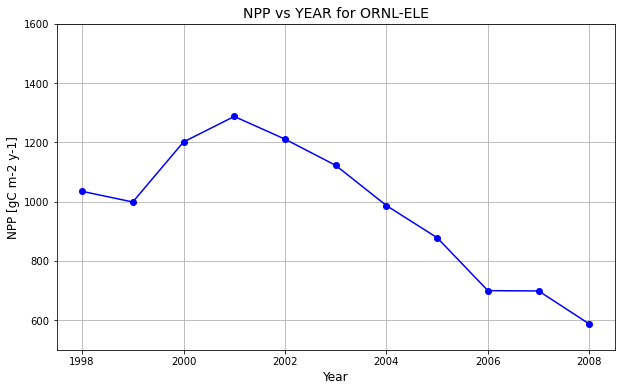

In [56]:
# Create a plot
plt.figure(figsize=(10, 6))
site = "ORNL"
co2_case = "ELE"
df = dict_obs_ax[site][co2_case]
plt.plot(df['YEAR'], df['NPP'], marker='o', linestyle='-', color='b')

# Adding title and labels
plt.title(f'NPP vs YEAR for {site}-{co2_case}', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel(f'NPP [{NPP_units}]', fontsize=12)
plt.ylim (500, 1600) 
# Show grid and the plot
plt.grid(True)
plt.show()

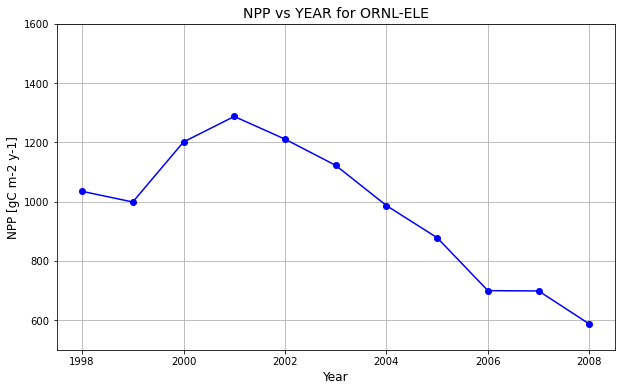

In [57]:
# Create a plot
plt.figure(figsize=(10, 6))

site = "ORNL"
co2_case = "ELE"
df = dict_obs_ax[site][co2_case]
plt.plot(df['YEAR'], df['NPP'], marker='o', linestyle='-', color='b')

# Adding title and labels
plt.title(f'NPP vs YEAR for {site}-{co2_case}', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel(f'NPP [{NPP_units}]', fontsize=12)
plt.ylim (500, 1600) 
# Show grid and the plot
plt.grid(True)
plt.show()

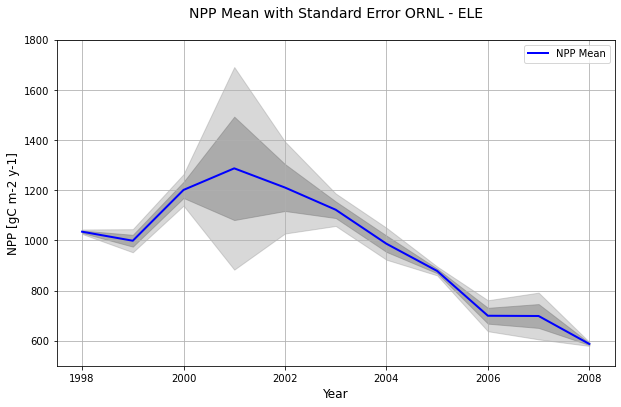

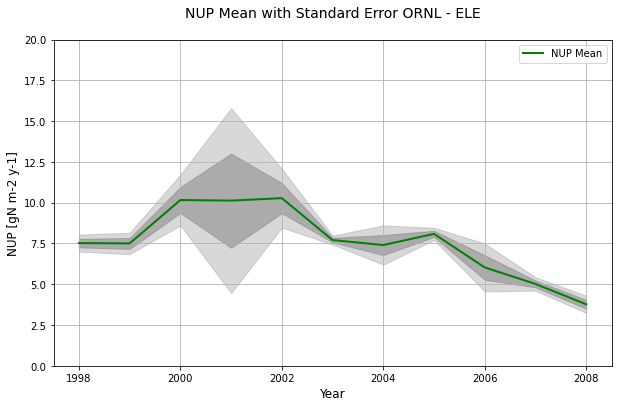

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data from the provided dataframes
# Assuming Mean_DF and Standard_error_DF are pandas DataFrames


site = "ORNL"
co2_case = "ELE"

Mean_DF = dict_obs_ax[site][co2_case]
Standard_error_DF = dict_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']

mean_nup = Mean_DF['NUP']
se_nup = Standard_error_DF['NUP']

# Create the figure and axis
plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='NPP Mean', color='blue', lw=2)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, color='gray', alpha=0.5)
plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color='gray', alpha=0.3)

# Add labels and title
plt.xlabel('Year',fontsize=12 )
plt.ylabel(f'NPP [{NPP_units}]', fontsize=12)
plt.title(f'NPP Mean with Standard Error {site} - {co2_case}\n', fontsize= 14)
plt.legend()
plt.ylim (500, 1800) 
# Show grid and the plot
plt.grid(True)
# Display the plot
plt.show()


plt.figure(figsize=(10, 6))
# Plot NUP with shaded error bars (optional, if you want it on the same plot)
plt.plot(years, mean_nup, label='NUP Mean', color='green', lw=2)
plt.fill_between(years, mean_nup - se_nup, mean_nup + se_nup, color='gray', alpha=0.5)
plt.fill_between(years, mean_nup - se_nup*1.96, mean_nup + se_nup*1.96, color='gray', alpha=0.3)

plt.xlabel('Year', fontsize=12)
plt.ylabel(f'NUP [{NUP_units}]', fontsize=12)
plt.title(f'NUP Mean with Standard Error {site} - {co2_case}\n', fontsize= 14)
plt.legend()
plt.ylim (0, 20) 
# Show grid and the plot
plt.grid(True)
plt.show()

In [60]:
Mean_DF

,YEAR,co2,site,NPP,NUP
rownames,,,,,
12,1998.0,ELE,ORNL,1034.5,7.525
13,1999.0,ELE,ORNL,998.5,7.505
14,2000.0,ELE,ORNL,1201.0,10.165
15,2001.0,ELE,ORNL,1287.0,10.130
16,2002.0,ELE,ORNL,1210.5,10.280
17,2003.0,ELE,ORNL,1122.0,7.710
18,2004.0,ELE,ORNL,986.5,7.405
19,2005.0,ELE,ORNL,878.0,8.090
20,2006.0,ELE,ORNL,699.5,6.030


In [61]:
# Read models outputs

# Inputs Models (edit what you want)
- Choose one CO2 case
- Choose RD or ECA

In [62]:


case_id_runs = ["FACE_1PFT_r241009_BASE_Log19_StoreMax",
]
co2_case = CO2_cases[1] # 0: amb ; 1 :ele

fn = "RD" #RD ECA

fns = ["RD", "ECA"]
fns = ["RD",]

plotly_plots = "y"    
if plotly_plots in ["yes", "y", "YES", "Y"]:
    print ("plotly plots will be plotted" )

plotly plots will be plotted


In [63]:
print (co2_case)

ELE


# Input how many constaints you want to put
Read more [here](https://docs.google.com/presentation/d/1ThmCmvyMYaTbEaALI3XM_UsLA8jH14Dg2tPUYU5xEgM/edit#slide=id.g3022fef1e16_0_67)

In [64]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"
dict_model_sites= {"ORNL" : "US-ORN", "DUKE" : "US-DUK"}
#run_case = "eCO2"
run_CO2_case = {"AMB":"aCO2", "ELE":"eCO2"}


In [65]:
co2_case

'ELE'

In [66]:
dict_files = {}
for site in sites_o:
    dict_files[site]  ={}
    for case_id_run in case_id_runs:
        case_id = f"{case_id_run}_{fn}"
        dict_files[site][f"{case_id_run}_{fn}_{run_CO2_case[co2_case]}"] = f"{path_in}{case_id}_processed/{case_id}_{dict_model_sites[site]}_{run_CO2_case[co2_case]}.nc"

In [67]:
f"{path_in}{case_id}_processed"

'/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r241009_BASE_Log19_StoreMax_RD_processed'

In [68]:
f"{case_id}_{dict_model_sites[site]}_{run_CO2_case[co2_case]}"

'FACE_1PFT_r241009_BASE_Log19_StoreMax_RD_US-ORN_eCO2'

In [69]:
dict_files[site].keys()

dict_keys(['FACE_1PFT_r241009_BASE_Log19_StoreMax_RD_eCO2'])

In [70]:
# initializing the empty dictionary
ds_full = {}
dict_list_keys = {}
for site in sites_o:
#for site in ["DUKE",]:
    ds_full[site] = {}
    dict_list_keys[site] = []


In [71]:
failed_keys  = ["r240914a_RD_aCO2_en23",
                "r240914a_RD_aCO2_en29",
                "r240914a_ECA_aCO2_en32",
                "r240914a_ECA_aCO2_en36",
                "r240914b_ECA_aCO2_en38",
                "r240914e_ECA_aCO2_en38",
                "r240914c_ECA_aCO2_en29",
                "r240914a_ECA_aCO2_en9",
                "r240914a_ECA_aCO2_en37",
                "r240914a_RD_aCO2_en16",
                "r240914b_RD_aCO2_en13",
                "r240914b_RD_aCO2_en20",
                "r240914c_RD_aCO2_en13",
                "r240914c_RD_aCO2_en20",
                "r240914d_RD_aCO2_en3",
                "r240914c_ECA_eCO2_en29",
                "r240914a_ECA_eCO2_en9",
                "r240914a_ECA_eCO2_en32",
                "r240914a_ECA_eCO2_en36",
                "r240914a_ECA_eCO2_en37",
                "r240914a_RD_eCO2_en16",
                "r240914a_RD_eCO2_en23",
                "r240914b_RD_eCO2_en13",
                "r240914b_RD_eCO2_en20",
                "r240914c_RD_eCO2_en13",
                "r240914c_RD_eCO2_en20",
                "r240914a_RD_eCO2_en29",
                "r240914d_RD_eCO2_en3",
                ]

In [72]:

for site in sites_o:
    for key in dict_files[site].keys():
        print (key, site)
        if key in dict_list_keys[site]:
            continue
        if key not in failed_keys:
            dict_list_keys[site].append(key)
            ds_full[site][f"{key}"]=xr.open_mfdataset(dict_files[site][key])
            print (f"fail: {key}")

FACE_1PFT_r241009_BASE_Log19_StoreMax_RD_eCO2 ORNL


OSError: no files to open

In [73]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_EXCESS_RESP",
        #"FATES_L2FR",
        #"FATES_NCOHORTS",
        #"TLAI", 
        #"FATES_AUTORESP",
        "FATES_NPP_Minus_EXCESS_RESP",
        "NUP",
        #"CUE",
        #"NET_NMIN",
       #"TOTSOMC",
       #"TOTSOMN",
       )
var = vars[0]

In [74]:
params_fname = "vmax_r240615b_RD.csv"
params_fname = "vmax_r240620_RD.csv"
params_fname = "vmax_r240620_ECA.csv"
params_fname = "vmax_r240701_ECA.csv"
params_fname = "vmax_r240701_ECA.xlsx"
params_fname = "vmax_r240703_ECA"
params_fname = "vmax_r240902_RD" 
#params_fname = "vcmax_r240802"# 37 ensembles
#params_fname = "baserate_240830" # 42 ensembles
params_fname = f"vmax_r240913_{fn}" # 37 ensembles
#params_fname = "vmax_r240913_RD" # 37 ensembles
#params_fname = "vmax_r240728_ECA" # 31 ensembles
#params_fname = "baserate_240912" # 21 ensembles
try:
    #df_vmax_values = pd.read_csv(f"{path_in}{case_id}_processed/{params_fname}.csv")
    #df_vmax_values = pd.read_excel(f"{path_in}{case_id}_processed/{params_fname}.xlsx")
    df_vmax_values = pd.read_excel(f"{path_in}Ensemble_vals/{params_fname}.xlsx")
    print (df_vmax_values)
    list_legend = df_vmax_values['fates_cnp_vmax_nh4'].values
    #list_legend = df_vmax_values['vcmax_vals'].values
    #list_legend = df_vmax_values['non_leaf'].values
except:
    path_tmp = f"{path_in}Ensemble_vals/{params_fname}.xlsx"
    print (".......\nParams file not read | Try again\n.......")
    print (path_tmp)
    pass


# Convert to list of formatted strings
formatted_list = [f"NH4_{nh4:.01e}_P_{p:.01e}" for nh4, p in zip(df_vmax_values['fates_cnp_vmax_nh4'], df_vmax_values['fates_cnp_vmax_p'])]
#formatted_list = [f"Leaf_{nh4:.01e}_NonLeaf_{p:.01e}" for nh4, p in zip(df_vmax_values['leaf'], df_vmax_values['non_leaf'])]
#formatted_list

    RD  fates_cnp_vmax_nh4  fates_cnp_vmax_no3  fates_cnp_vmax_p
0    1        1.000000e-10        1.000000e-10      1.000000e-11
1    2        2.000000e-10        2.000000e-10      2.000000e-11
2    3        3.000000e-10        3.000000e-10      3.000000e-11
3    4        4.000000e-10        4.000000e-10      4.000000e-11
4    5        5.000000e-10        5.000000e-10      5.000000e-11
5    6        6.000000e-10        6.000000e-10      6.000000e-11
6    7        7.000000e-10        7.000000e-10      7.000000e-11
7    8        8.000000e-10        8.000000e-10      8.000000e-11
8    9        9.000000e-10        9.000000e-10      9.000000e-11
9   10        1.000000e-09        1.000000e-09      1.000000e-10
10  11        2.000000e-09        2.000000e-09      2.000000e-10
11  12        3.000000e-09        3.000000e-09      3.000000e-10
12  13        4.000000e-09        4.000000e-09      4.000000e-10
13  14        5.000000e-09        5.000000e-09      5.000000e-10
14  15        6.000000e-0

In [75]:
def read_nc_data (ds, site, sel_var, keys):
    data = {}
    for key in keys:
        if True:
            print (sel_var,key)
            #case_id = key.split("_")[0]
            if True:#(site in key) and (run_case in key) and (case_id in key):
                #li = int(key.split("_")[-1][2:])-1
            #if True:
                if "FATES_NPP_Minus_EXCESS_RESP" in [sel_var,]:
                    #text_units = ds[site][key]["FATES_NPP"].attrs["units"]
                    #data[f"{formatted_list[li]}"] = ds[site][key]["FATES_NPP"].values.reshape(-1) - ds[site][key]["FATES_EXCESS_RESP"].values.reshape(-1)
                    data[f"{key}"] = (ds[site][key]["FATES_NPP"].resample(time='A').sum().values.reshape(-1)  - ds[site][key]["FATES_EXCESS_RESP"].resample(time='A').sum().values.reshape(-1))*1000*24*60*60
                    var = "FATES_NPP"
                    text_add_var = "_Minus_EXCESS_RESP"
                    var_units = "gC m-2 y-1"
                elif "NUP" in [sel_var,]:
                    #text_units = ds[site][key]["FATES_NH4UPTAKE"].attrs["units"]
                    data[f"{key}"] = (ds[site][key]["FATES_NH4UPTAKE"].resample(time='A').sum().values.reshape(-1)  + ds[site][key]["FATES_NO3UPTAKE"].resample(time='A').sum().values.reshape(-1))*1000*24*60*60
                    var = "FATES_NH4UPTAKE"
                    text_add_var = "+FATES_NO3UPTAKE"
                    var_units = "gN m-2 y-1"
                ktmp = key
                #li+=1

    try: 
        if var == "CUE":
            var = "FATES_NPP"  
    except:
        pass

    #time = np.arange(0,len(ds[site][ktmp][var].values.reshape(-1)))
    time = ds[site][ktmp][var].resample(time='A').sum().time

    data['date'] = time
    df = pd.DataFrame(data)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna( how="all", inplace=True)
    
    ts_year = []
    for d in df["date"]:
        ts_year.append(pd.to_datetime(d.isoformat()).year)
    df["Year"] = ts_year
    df = df.drop(columns=['date'])
    return df,text_add_var,var_units

In [76]:
vars

('FATES_NPP_Minus_EXCESS_RESP', 'NUP')

In [77]:
dict_df = {}
text_add_var = {}
text_var_units = {}
for site in sites_o:
    print (site)
    dict_df[site] = {}
    text_add_var[site] = {}
    text_var_units[site] = {}
    for var in vars:
        #try:
        dict_df[site][var], text_add_var[site][var], text_var_units[site][var]  = read_nc_data (ds_full, site,var, ds_full[site].keys())
        #except:
        #    pass
    
    
    

ORNL


UnboundLocalError: local variable 'ktmp' referenced before assignment

### Standard_Error = std/(n^0.5)

In [78]:
dict_df_model_se = {}
for site in sites_o:
    dict_df_model_se[site] = {}
    for var in vars:
        cols_select = dict_df[site][var].columns[:-1]
        print (cols_select,var)
        dict_df_model_se[site][var] = dict_df[site][var].copy(deep=True)
        dict_df_model_se[site][var]["mean"] = dict_df[site][var][cols_select].mean(axis=1)
        dict_df_model_se[site][var]["std"] = dict_df[site][var][cols_select].std(axis=1)
        dict_df_model_se[site][var]["se"] = dict_df_model_se[site][var]["std"]/(len(cols_select)**0.5)
        dict_df_model_se[site][var] = dict_df_model_se[site][var].drop(columns=cols_select)
        


KeyError: 'FATES_NPP_Minus_EXCESS_RESP'

In [79]:
# Set the year as the index
site = "DUKE"


df = dict_df[site]["FATES_NPP_Minus_EXCESS_RESP"]
years = df["Year"]
#df.set_index('Year', inplace=True)

# Plot the data
plt.figure(figsize=(9, 6))
for column in list(df.columns)[:-1]:
    plt.plot(years, df[column], marker='o', label=column, color="red")
    
mean_model = dict_df_model_se[site]["FATES_NPP_Minus_EXCESS_RESP"]["mean"]
se_model = dict_df_model_se[site]["FATES_NPP_Minus_EXCESS_RESP"]["se"]
plt.plot(years, mean_model, label='NPP Mean Model', color='darkred', lw=3)
plt.fill_between(years, mean_model - se_model, mean_model + se_model, color='brown', alpha=0.5)
plt.fill_between(years, mean_model - se_model*1.96, mean_model + se_model*1.96, color='brown', alpha=0.3)

plt.title(f'NPP for Multi Model {site} - {co2_case}\n', fontsize= 14)
#plt.xlabel('Year')
plt.ylabel(f'NPP [{NPP_units}]', fontsize=12)
plt.legend()
plt.ylim (1000, 2000) 
plt.grid()
plt.show()
#print (no_check)

KeyError: 'DUKE'

In [80]:
# Set the year as the index
site = "DUKE"
plot_var = "NUP"

df = dict_df[site][plot_var]
years = df["Year"]
#df.set_index('Year', inplace=True)

# Plot the data
plt.figure(figsize=(20, 12))
for column in list(df.columns)[:-1]:
    plt.plot(years, df[column], marker='o', label=column)#, color="blue")

mean_model = dict_df_model_se[site]["NUP"]["mean"]
se_model = dict_df_model_se[site]["NUP"]["se"]
plt.plot(years, mean_model, label='NUP Mean Model', color='darkred', lw=3)
plt.fill_between(years, mean_model - se_model, mean_model + se_model, color='brown', alpha=0.5)
plt.fill_between(years, mean_model - se_model*1.96, mean_model + se_model*1.96, color='brown', alpha=0.3)
    

plt.title(f'NUP for Multi Model {site} - {co2_case}\n', fontsize= 14)
#plt.xlabel('Year')
plt.ylabel(f'NUP [{NUP_units}]', fontsize=12)
#plt.legend()
plt.ylim (0, 20) 
plt.grid()
plt.show()

KeyError: 'DUKE'

## Mean and SE

In [81]:
# Set the year as the index
site = "DUKE"
print (co2_case, fn)

df = dict_df[site]["FATES_NPP_Minus_EXCESS_RESP"]
years = df["Year"]
#df.set_index('Year', inplace=True)

# Plot the data
plt.figure(figsize=(20, 12))
for column in list(df.columns)[:-1]:
    plt.plot(years, df[column], linestyle='--', marker='o', label=column, color="brown", alpha=0.5)
    
    
mean_model = dict_df_model_se[site]["FATES_NPP_Minus_EXCESS_RESP"]["mean"]
se_model = dict_df_model_se[site]["FATES_NPP_Minus_EXCESS_RESP"]["se"]
plt.plot(years, mean_model, label='NPP Mean Model', color='darkred', lw=3)
plt.fill_between(years, mean_model - se_model, mean_model + se_model, color='brown', alpha=0.7)
plt.fill_between(years, mean_model - se_model*1.96, mean_model + se_model*1.96, color='brown', alpha=0.5)


Mean_DF = dict_obs_ax[site][co2_case]
Standard_error_DF = dict_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='NPP Mean', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, color='gray', alpha=0.5)
plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color='gray', alpha=0.3)

# Add labels and title
plt.xlabel('Year',fontsize=12 )
plt.ylabel(f'NPP [{NPP_units}]', fontsize=12)
plt.title(f'NPP Models and Obs {site} - {co2_case} - {fn}\n', fontsize= 14)
#plt.legend()
plt.ylim (0, 2000) 
# Show grid and the plot
plt.grid(True)
# Display the plot
#plt.show()


ELE RD


KeyError: 'DUKE'

In [82]:
# Set the year as the index
site = "DUKE"
print (co2_case, fn)

df = dict_df[site]["NUP"]
years = df["Year"]
#df.set_index('Year', inplace=True)

# Plot the data
plt.figure(figsize=(20, 12))
for column in list(df.columns)[:-1]:
    plt.plot(years, df[column], linestyle='--', marker='o', label=column, color="brown", alpha=0.7)
    
    
mean_model = dict_df_model_se[site]["NUP"]["mean"]
se_model = dict_df_model_se[site]["NUP"]["se"]
plt.plot(years, mean_model, label='NUP Mean Model', color='darkred', lw=3)
plt.fill_between(years, mean_model - se_model, mean_model + se_model, color='brown', alpha=0.5)
plt.fill_between(years, mean_model - se_model*1.96, mean_model + se_model*1.96, color='brown', alpha=0.3)


Mean_DF = dict_obs_ax[site][co2_case]
Standard_error_DF = dict_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NUP']
se_npp = Standard_error_DF['NUP']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='NUP Mean', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, color='gray', alpha=0.5)
plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color='gray', alpha=0.3)

# Add labels and title
plt.xlabel('Year',fontsize=12 )
plt.ylabel(f'NUP [{NPP_units}]', fontsize=12)
plt.title(f'NUP Models and Obs {site} - {co2_case} - {fn}\n', fontsize= 14)
#plt.legend()
plt.ylim (0, 20) 
# Show grid and the plot
plt.grid(True)
# Display the plot
plt.show()


ELE RD


KeyError: 'DUKE'

In [83]:
print (site, co2_case, fn, var)

DUKE ELE RD FATES_NPP_Minus_EXCESS_RESP


In [84]:
print (dict_df.keys())
for key in dict_df.keys():
    print (dict_df[key].keys())


dict_keys(['ORNL'])
dict_keys([])


In [85]:
dict_df

{'ORNL': {}}

In [40]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Plotly Plots

In [263]:
# Build the following with 
## - sites_o
## - CO2_cases
## - RD ECA
## - checks 3#
## - vars : FATES_NPP_Minus_EXCESS_RESP



In [50]:
sites_o

('DUKE',)

# Run the following cell only once, then turn to raw

In [42]:
dict_plotly = {}
for site in sites_o:
    dict_plotly[site] = {}
    for co2_case in CO2_cases:
        dict_plotly[site][co2_case] = {}
        for fn in ["RD", "ECA"]:
            dict_plotly[site][co2_case][fn] = {}
            for min_checks in [1,2,3]:
                dict_plotly[site][co2_case][fn][min_checks] = {}
                #if True:
                #    # vars
                #    dict_plotly[site][co2_case][fn][min_checks]["FATES_NPP_Minus_EXCESS_RESP"] = 
                #    dict_plotly[site][co2_case][fn][min_checks]["NUP"] = 

### We have in the previous run 

In [43]:
print (site, co2_case, fn, var)

DUKE ELE ECA NUP


In [44]:
# run this one by one
for site in sites_o:
    for var in vars:
        dict_plotly[site][co2_case][fn][var] = dict_df[site][var]

In [45]:
dict_plotly['DUKE']['AMB']['RD'].keys()

dict_keys([1, 2, 3])

In [267]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [268]:
# After you have the cases run for reponse

In [46]:
# Response:
dict_plotly_response = {}
for site in sites_o:
    dict_plotly_response[site] = {}
    for fn in fns:
        dict_plotly_response[site][fn] = {}

In [47]:
for site in sites_o:
    for fn in fns:
        for var in vars:
            dict_plotly_response[site][fn][var] = dict_plotly[site]["ELE"][fn][var] - dict_plotly[site]["AMB"][fn][var]
            dict_plotly_response[site][fn][var]["Year"] = dict_plotly[site]["ELE"][fn][var]["Year"]

KeyError: 'FATES_NPP_Minus_EXCESS_RESP'

In [48]:
dict_plotly[site]["AMB"][fn][var]

KeyError: 'FATES_NPP_Minus_EXCESS_RESP'

In [49]:
dict_plotly[site]["ELE"][fn][var]

KeyError: 'FATES_NPP_Minus_EXCESS_RESP'

## Plotly Plots Ensembles

In [273]:
path_html_save = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots"
co2_case = CO2_cases[1]
print (co2_case)

ELE


In [274]:
for site in sites_o:
    for var in vars:
        for fn in fns:
            # model en
            df_tmp = dict_plotly[site][co2_case][fn][var].copy(deep=True)
            df_save_tmp_mods = pd.DataFrame(df_tmp.mean())
            #obs
            if var == "FATES_NPP_Minus_EXCESS_RESP":
                var_tmp = "NPP"
            else:
                var_tmp = var
            mean_ar = dict_obs_ax[site][co2_case][var_tmp].values
            lower_bound = dict_obs_ax[site][co2_case][var_tmp].values - dict_obs_ase[site][co2_case][var_tmp].values
            upper_bound = dict_obs_ax[site][co2_case][var_tmp].values + dict_obs_ase[site][co2_case][var_tmp].values
            df_save_tmp_obs = pd.DataFrame(
                {
                    'Mean': mean_ar,
                    'Lower Bound': lower_bound,
                    'Upper Bound': upper_bound
                },
                index=np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int)
            )
            
            
            
            df_save_tmp_mods.to_csv(f"{path_html_save}/mods_summary_{var}_{site}_{fn}_{co2_case}_singlerun.csv")
            df_save_tmp_obs.to_csv(f"{path_html_save}/obs_summary_{var}_{site}_{fn}_{co2_case}_singlerun.csv")

DUKE
FATES_NPP_Minus_EXCESS_RESP
FATES_NPP_Minus_EXCESS_RESP_DUKE_RD_ELE_singlerun_line_plot.html


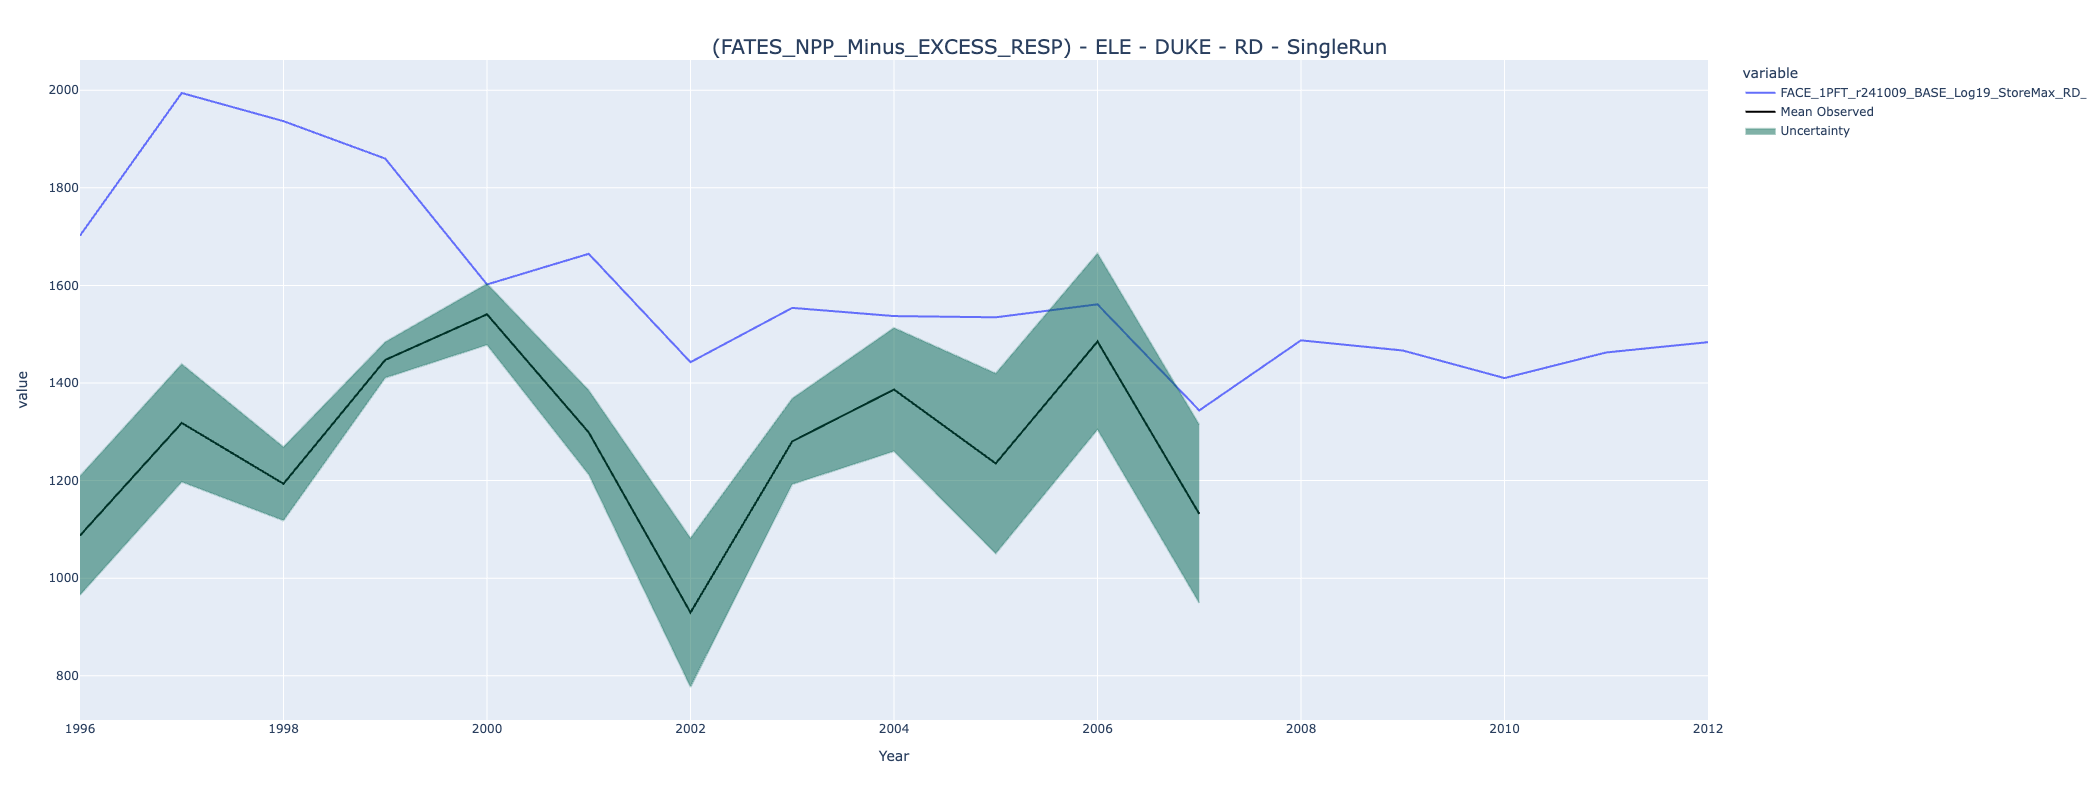

NUP
NUP_DUKE_RD_ELE_singlerun_line_plot.html


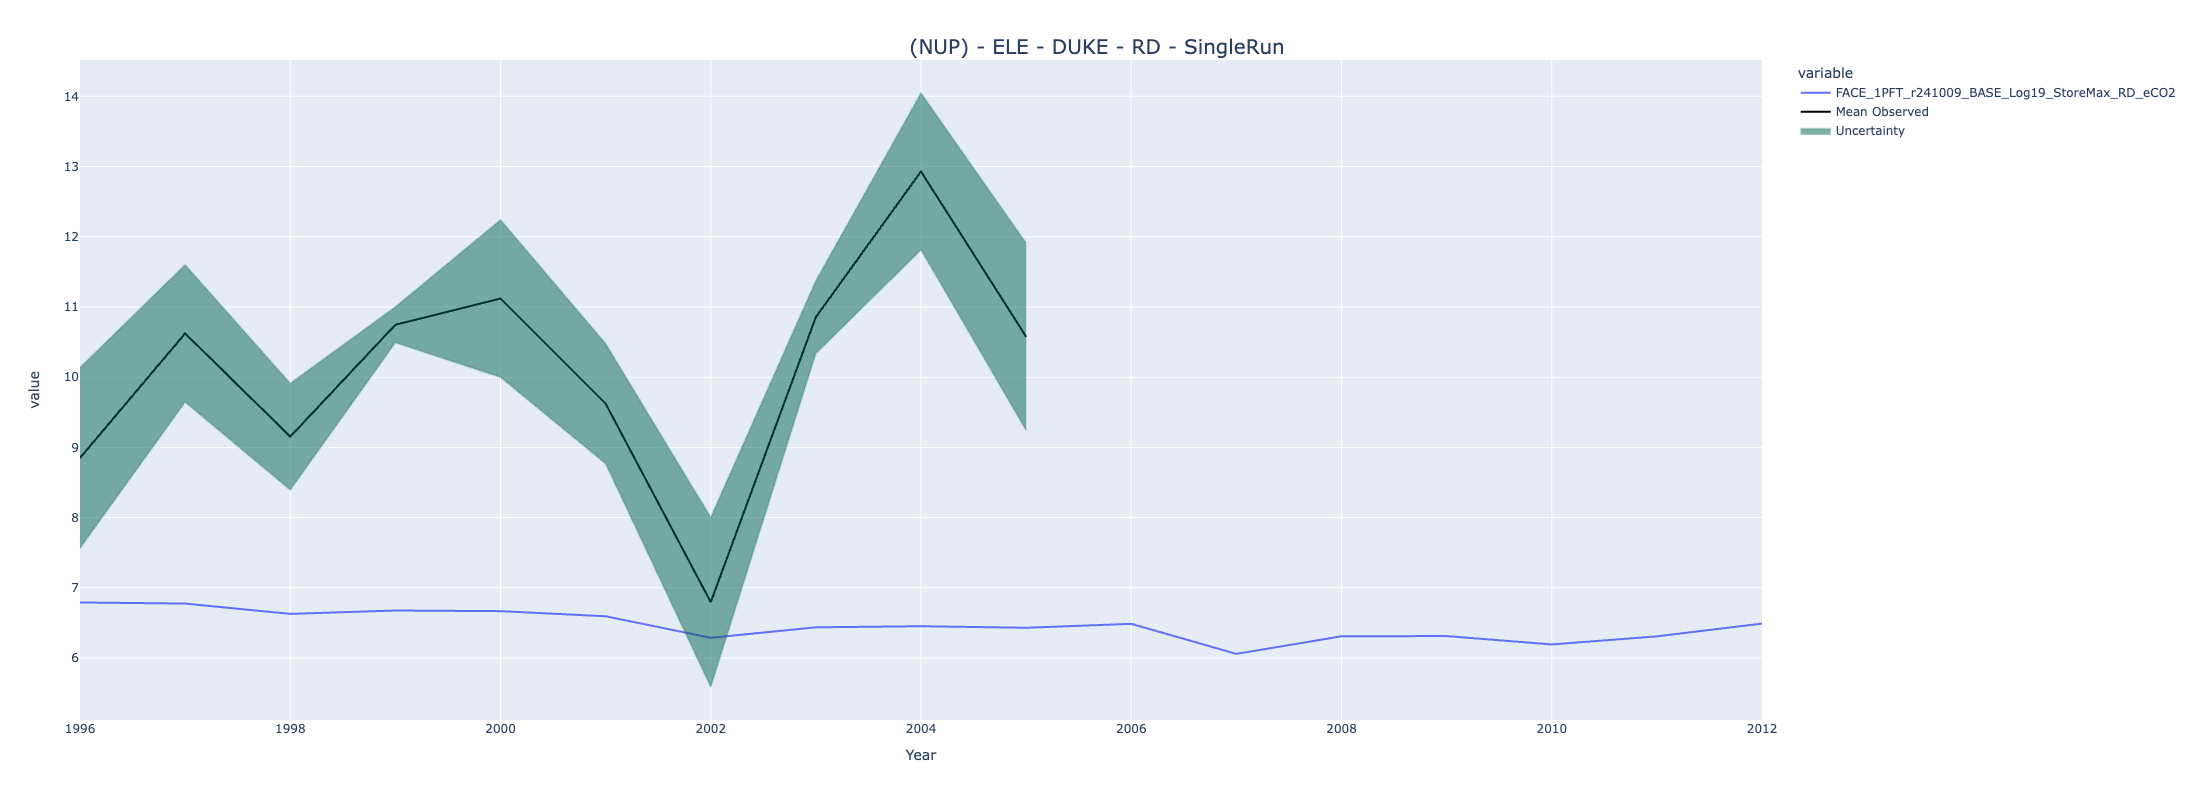

In [275]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
if plotly_plots in ["yes", "y", "YES", "Y"]:
    for site in sites_o:
        print(site)
        for var in vars:
            print (var)
            for fn in fns:
                df_tmp = dict_plotly[site][co2_case][fn][var].copy(deep=True)
                #df_tmp = dict_df[site][var].copy(deep=True)
                if var == "FATES_NPP_Minus_EXCESS_RESP":
                    var_tmp = "NPP"
                else:
                    var_tmp = var

                fig = px.line(df_tmp[:], x="Year", y=df_tmp.columns,
                  hover_data={"Year": "%Y"},)
                fig.add_scatter(x=np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int), 
                            y=dict_obs_ax[site][co2_case][var_tmp].values, 
                            mode='lines', 
                            name='Mean Observed', line=dict(color='black', width=2))
            
                # Add a filled polygon (e.g., for uncertainty)
                # Example: creating upper and lower bounds
                lower_bound = dict_obs_ax[site][co2_case][var_tmp].values - dict_obs_ase[site][co2_case][var_tmp].values
                upper_bound = dict_obs_ax[site][co2_case][var_tmp].values + dict_obs_ase[site][co2_case][var_tmp].values

                # Fill between the lower and upper bounds
                fig.add_traces([
                    go.Scatter(
                    x=df_tmp['Year'], y=upper_bound, 
                    fill=None, mode='lines', line=dict(color='rgba(0,100,80,0.2)'), 
                    showlegend=False
                ),
                go.Scatter(
                    x=df_tmp['Year'], y=lower_bound, 
                    fill='tonexty', mode='lines', line=dict(color='rgba(0,100,80,0.2)'), 
                    name='Uncertainty'
                )
            ])
            
            
                # Update layout with a custom title
                fig.update_layout(
                title={
                    'text': f" ({var}) - {co2_case} - {site} - {fn} - SingleRun ",
                    'y': 0.95,  # Position title slightly above the plot
                    'x': 0.5,  # Center the title horizontally
                    'xanchor': 'center',
                    'yanchor': 'top'
                },
                title_font=dict(size=20),  # Adjust the font size of the title
                width=1200, height=800  # Adjust width and height as needed
            )

                # Save the plot as an HTML file
                #fig.write_html(f"{path_html_save}/{var}_{site}_{fn}_{co2_case}_singlerun_line_plot.html")

                print (f"{var}_{site}_{fn}_{co2_case}_singlerun_line_plot.html")

                # Show the plot
                fig.show()

# Saving the data for combined plots

In [276]:
# Set the year as the index
site = "DUKE"

print (co2_case, fn)

save_dir = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots"
# OBS

dict_obs_ax[site][co2_case].to_csv(f"{save_dir}/obs_ax_{site}_{co2_case}.csv")
dict_obs_ase[site][co2_case].to_csv(f"{save_dir}/obs_ase_{site}_{co2_case}.csv")
for site in sites_o:
    dict_df_model_se[site]["FATES_NPP_Minus_EXCESS_RESP"].to_csv(f"{save_dir}/Model_NPP_{fn}_{site}_{co2_case}_singlerun.csv")
    dict_df_model_se[site]["NUP"].to_csv(f"{save_dir}/Model_NUP_{fn}_{site}_{co2_case}_singlerun.csv")
#se_model = dict_df_model_se[site]["NUP"]["se"]
#std_model = dict_df_model_se[site]["NUP"]["std"]


ELE RD


### Plotly Response Ensembles

In [170]:

Mean_DF1 = dict_plot_data_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
Mean_DF0 = dict_plot_data_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

Mean_DF = Mean_DF1[["YEAR","NPP", "NUP"]] - Mean_DF0[["YEAR","NPP", "NUP"]]
Mean_DF["YEAR"] = Mean_DF1["YEAR"]

Standard_error_DF1 = dict_plot_data_obs_ase[site][CO2_cases[1]].reset_index(drop=True)
Standard_error_DF0 = dict_plot_data_obs_ase[site][CO2_cases[0]].reset_index(drop=True)

Standard_error_DF = ((Standard_error_DF1[["YEAR","NPP", "NUP"]])**2 + (Standard_error_DF0[["YEAR","NPP", "NUP"]])**2)**.5
Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]

# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']


NameError: name 'dict_plot_data_obs_ax' is not defined

#### Save excel summary

In [ ]:
for site in sites_o:
    for var in vars:
        for fn in fns:
            # model en
            df_tmp = dict_plotly_response[site][fn][min_checks][var].copy(deep=True)
            df_save_tmp_mods = pd.DataFrame(df_tmp.mean())
            #obs
            if var == "FATES_NPP_Minus_EXCESS_RESP":
                var_tmp = "NPP"
            else:
                var_tmp = var
            mean_ar = dict_obs_ax[site][CO2_cases[1]][var_tmp].values - dict_obs_ax[site][CO2_cases[0]][var_tmp].values
            SE = ((dict_obs_ase[site][CO2_cases[0]][var_tmp].values)**2 + (dict_obs_ase[site][CO2_cases[1]][var_tmp].values)**2)**0.5
            lower_bound = dict_obs_ax[site][CO2_cases[1]][var_tmp].values - dict_obs_ax[site][CO2_cases[0]][var_tmp].values - SE
            upper_bound = dict_obs_ax[site][CO2_cases[1]][var_tmp].values - dict_obs_ax[site][CO2_cases[0]][var_tmp].values + SE
            df_save_tmp_obs = pd.DataFrame(
                {
                    'Mean': mean_ar,
                    'Lower Bound': lower_bound,
                    'Upper Bound': upper_bound
                },
                index=np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int)
            )
            
            
            
            df_save_tmp_mods.to_csv(f"{path_html_save}/mods_summary_Response_{var}_{site}_{fn}_minC{min_checks}_{add_text_check}.csv")
            df_save_tmp_obs.to_csv(f"{path_html_save}/obs_summary_Response_{var}_{site}_{fn}_minC{min_checks}_{add_text_check}.csv")

In [ ]:
pd.DataFrame(
    {
        'Mean': mean_ar,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    },
    index=np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int)
)


In [ ]:
! open /Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots/.

In [ ]:
np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
if plotly_plots in ["yes", "y", "YES", "Y"]:
    for site in sites_o:
        print(site)
        for var in vars:
            print (var)
            for fn in fns:
                df_tmp = dict_plotly_response[site][fn][min_checks][var].copy(deep=True)
                #df_tmp = dict_df[site][var].copy(deep=True)
                if var == "FATES_NPP_Minus_EXCESS_RESP":
                    var_tmp = "NPP"
                else:
                    var_tmp = var

                fig = px.line(df_tmp[:], x="Year", y=df_tmp.columns,
                  hover_data={"Year": "%Y"},)
                fig.add_scatter(x=np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int), 
                            y=dict_obs_ax[site][CO2_cases[1]][var_tmp].values - dict_obs_ax[site][CO2_cases[0]][var_tmp].values, 
                            mode='lines', 
                            name='Mean Observed', line=dict(color='black', width=2))
            
                # Add a filled polygon (e.g., for uncertainty)
                # Example: creating upper and lower bounds
                SE = ((dict_obs_ase[site][CO2_cases[0]][var_tmp].values)**2 + (dict_obs_ase[site][CO2_cases[1]][var_tmp].values)**2)**0.5
                lower_bound = dict_obs_ax[site][CO2_cases[1]][var_tmp].values - dict_obs_ax[site][CO2_cases[0]][var_tmp].values - SE
                upper_bound = dict_obs_ax[site][CO2_cases[1]][var_tmp].values - dict_obs_ax[site][CO2_cases[0]][var_tmp].values + SE

                # Fill between the lower and upper bounds
                fig.add_traces([
                    go.Scatter(
                    x=df_tmp['Year'], y=upper_bound, 
                    fill=None, mode='lines', line=dict(color='rgba(0,100,80,0.2)'), 
                    showlegend=False
                ),
                go.Scatter(
                    x=df_tmp['Year'], y=lower_bound, 
                    fill='tonexty', mode='lines', line=dict(color='rgba(0,100,80,0.2)'), 
                    name='Uncertainty'
                )
            ])
            
            
                # Update layout with a custom title
                fig.update_layout(
                title={
                    'text': f" (Response {var}) - {co2_case} - {site} - {fn} - Min Check {min_checks}  {add_text_check} ",
                    'y': 0.95,  # Position title slightly above the plot
                    'x': 0.5,  # Center the title horizontally
                    'xanchor': 'center',
                    'yanchor': 'top'
                },
                title_font=dict(size=20),  # Adjust the font size of the title
                width=1200, height=800  # Adjust width and height as needed
            )

                # Save the plot as an HTML file
                path_html_save = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots"
                fig.write_html(f"{path_html_save}/Response_{var}_{site}_{fn}_minC{min_checks}_line_plot.html")

                print (f"Response_{var}_{site}_{fn}_minC{min_checks}_line_plot.html")

                # Show the plot
                fig.show()

In [ ]:
path_html_save

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
if plotly_plots in ["yes", "y", "YES", "Y"]:
    for site in sites_o:
        print(site)
        for var in vars:
            print (var)
            df_tmp = dict_df[site][var].copy(deep=True)
            if var == "FATES_NPP_Minus_EXCESS_RESP":
                var_tmp = "NPP"
            else:
                var_tmp = var

            fig = px.line(df_tmp[:], x="Year", y=df_tmp.columns,
              hover_data={"Year": "%Y"},
              title=f" ({var}) - {site} \n")
            fig.add_scatter(x=np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int), 
                            y=dict_obs_ax[site][co2_case][var_tmp].values, 
                            mode='lines', 
                            name='Mean Observed', line=dict(color='black', width=2))
            
            # Add a filled polygon (e.g., for uncertainty)
            # Example: creating upper and lower bounds
            lower_bound = dict_obs_ax[site][co2_case][var_tmp].values + dict_obs_ase[site][co2_case][var_tmp].values
            upper_bound = dict_obs_ax[site][co2_case][var_tmp].values - dict_obs_ase[site][co2_case][var_tmp].values

            # Fill between the lower and upper bounds
            fig.add_traces([
                go.Scatter(
                    x=df_tmp['Year'], y=upper_bound, 
                    fill=None, mode='lines', line=dict(color='rgba(0,100,80,0.2)'), 
                    showlegend=False
                ),
                go.Scatter(
                    x=df_tmp['Year'], y=lower_bound, 
                    fill='tonexty', mode='lines', line=dict(color='rgba(0,100,80,0.2)'), 
                    name='Uncertainty'
                )
            ])
            
            
            # Update layout with a custom title
            fig.update_layout(
                title={
                    'text': f" ({var}) - {co2_case} - {site} - Min Check {min_checks}",
                    'y': 0.95,  # Position title slightly above the plot
                    'x': 0.5,  # Center the title horizontally
                    'xanchor': 'center',
                    'yanchor': 'top'
                },
                title_font=dict(size=20),  # Adjust the font size of the title
                width=1200, height=800  # Adjust width and height as needed
            )

            # Save the plot as an HTML file
            path_html_save = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots"
            #fig.write_html(f"{path_html_save}/{var}_{site}_{co2_case}_line_plot.html")

            print (f"{var}_{site}_{co2_case}_line_plot.html")

            # Show the plot
            fig.show()

In [ ]:
break

## Plots Mean and std (models); Mean and SE (obs)

In [ ]:
# Set the year as the index
site = "ORNL"
print (co2_case, fn)

# Plot the data
plt.figure(figsize=(20, 12))

# OBS

Mean_DF = dict_obs_ax[site][co2_case]
Standard_error_DF = dict_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df = dict_df[site]["FATES_NPP_Minus_EXCESS_RESP"]
years = df["Year"]
#df.set_index('Year', inplace=True)


# plot lines
#for column in list(df.columns)[:-1]:
#    plt.plot(years, df[column], linestyle='--', marker='o', label=column, color="brown", alpha=0.5)
    
    
mean_model = dict_df_model_se[site]["FATES_NPP_Minus_EXCESS_RESP"]["mean"]
se_model = dict_df_model_se[site]["FATES_NPP_Minus_EXCESS_RESP"]["se"]
std_model = dict_df_model_se[site]["FATES_NPP_Minus_EXCESS_RESP"]["std"]
plt.plot(years, mean_model, label=f'Model μ {fn}', color='blue', lw=3)
plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color='blue', alpha=0.4)
plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color='blue', alpha=0.2)


# Add labels and title
plt.xlabel('Year',fontsize=14 )
plt.ylabel(f'NPP [{NPP_units}]', fontsize=14)
plt.title(f'NPP Models and Obs {site} - {co2_case} - {fn} {min_checks}\n', fontsize= 16)
plt.legend(fontsize=14, loc="lower right")
plt.ylim (0, 2000) 
# Show grid and the plot
plt.grid(True)
# Display the plot
plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/NPP_Modex_{site}_{co2_case}_{fn}_Checks_{min_checks}.png",bbox_inches='tight')
plt.show()


In [ ]:
# Set the year as the index
site = "ORNL"
print (co2_case, fn)

# Plot the data
plt.figure(figsize=(20, 12))

# OBS

Mean_DF = dict_obs_ax[site][co2_case]
Standard_error_DF = dict_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NUP']
se_npp = Standard_error_DF['NUP']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df = dict_df[site]["FATES_NPP_Minus_EXCESS_RESP"]
years = df["Year"]
#df.set_index('Year', inplace=True)


# plot lines
#for column in list(df.columns)[:-1]:
#    plt.plot(years, df[column], linestyle='--', marker='o', label=column, color="brown", alpha=0.5)
    
    
mean_model = dict_df_model_se[site]["NUP"]["mean"]
se_model = dict_df_model_se[site]["NUP"]["se"]
std_model = dict_df_model_se[site]["NUP"]["std"]
plt.plot(years, mean_model, label=f'Model μ {fn}', color='blue', lw=3)
plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color='blue', alpha=0.4)
plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color='blue', alpha=0.2)


# Add labels and title
plt.xlabel('Year',fontsize=14 )
plt.ylabel(f'NUP [{NUP_units}]', fontsize=14)
plt.title(f'NUP Models and Obs {site} - {co2_case} - {fn} {min_checks}\n', fontsize= 16)
plt.legend(fontsize=14, loc="upper right")
plt.ylim (0, 20) 
# Show grid and the plot
plt.grid(True)
# Display the plot
plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/NUP_Modex_{site}_{co2_case}_{fn}_Checks_{min_checks}.png",bbox_inches='tight')
plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/NUP_Modex_{site}_{co2_case}_{fn}_Checks_{min_checks}.pdf",bbox_inches='tight')
plt.show()


AMB RD


In [ ]:
dict_obs_ase[site][co2_case]

In [ ]:
break

# Can be run independently

## Read processed data and plot

In [277]:
import matplotlib.pyplot as plt
import pandas as pd
import pyreadr
import xarray as xr
import numpy as np


In [278]:
save_dir = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots"
sites_o= ("ORNL", "DUKE" )
sites_o= ("DUKE", )

CO2_cases  = ("AMB", "ELE" )
# Units

NPP_units = "gC m$^{-2}$ y$^{-1}$"
NUP_units = "gN m$^{-2}$ y$^{-1}$"

In [279]:
# REading obs data
## site, CO2
dict_plot_data_obs_ax = {}
dict_plot_data_obs_ase = {}
for site in sites_o:
    dict_plot_data_obs_ax[site]={}
    dict_plot_data_obs_ase[site]={}
    for co2_case in CO2_cases:
        dict_plot_data_obs_ax[site][co2_case]= pd.read_csv(f"{save_dir}/obs_ax_{site}_{co2_case}.csv", index_col=0)
        dict_plot_data_obs_ase[site][co2_case]= pd.read_csv(f"{save_dir}/obs_ase_{site}_{co2_case}.csv", index_col=0)
        
# reading model data
## site, CO2, var, fN, checks

dict_plot_data_mod = {}
for site in sites_o:
    dict_plot_data_mod[site] = {}
    for co2_case in CO2_cases:
        dict_plot_data_mod[site][co2_case] = {}
        for fn in fns:
            dict_plot_data_mod[site][co2_case][fn] = {}
            if True:
                if True:
                    # vars
                    dict_plot_data_mod[site][co2_case][fn]["FATES_NPP_Minus_EXCESS_RESP"] = pd.read_csv(
                        f"{save_dir}/Model_NPP_{fn}_{site}_{co2_case}_singlerun.csv", index_col=0)
                    dict_plot_data_mod[site][co2_case][fn]["NUP"] = pd.read_csv(
                        f"{save_dir}/Model_NUP_{fn}_{site}_{co2_case}_singlerun.csv", index_col=0)
                    
                
        
    



## Select what to plot for NPP (final)

In [280]:
site = "DUKE"
co2_case = CO2_cases[1] # 0: amb ; 1 :ele
print (site, "\t", co2_case, "\t",fns , "\t" ) 

DUKE 	 ELE 	 ['RD'] 	


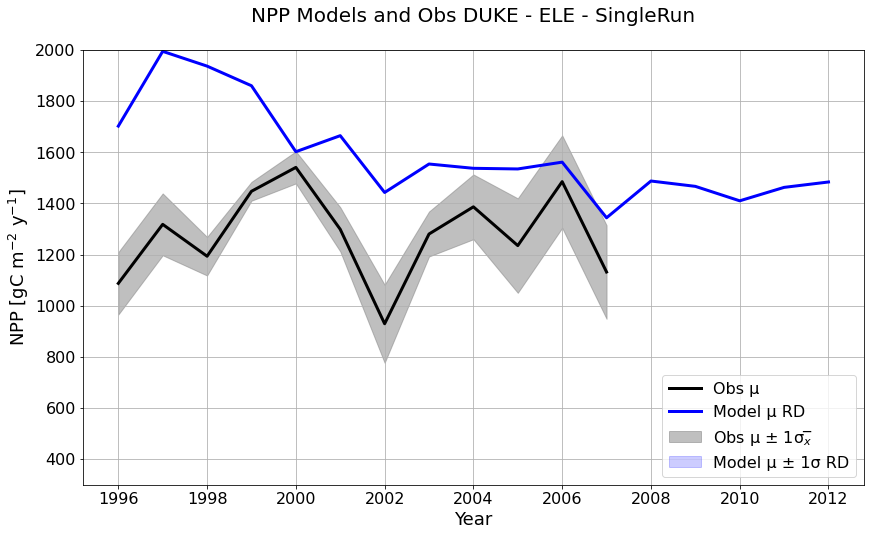

In [282]:
# Set the year as the index

# Plot the data
plt.figure(figsize=(14, 8))

# OBS

Mean_DF = dict_plot_data_obs_ax[site][co2_case]
Standard_error_DF = dict_plot_data_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
#plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df = dict_plot_data_mod[site][co2_case][fn]["FATES_NPP_Minus_EXCESS_RESP"]
years = df["Year"]

for fn in fns:
    mean_model = dict_plot_data_mod[site][co2_case][fn]["FATES_NPP_Minus_EXCESS_RESP"]["mean"]
    std_model  = dict_plot_data_mod[site][co2_case][fn]["FATES_NPP_Minus_EXCESS_RESP"]["std"]
    if fn == "RD": color_fn = "blue"
    if fn == "ECA" : color_fn = "green"
    plt.plot(years, mean_model, label=f'Model μ {fn}', color=color_fn, lw=3)
    plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color=color_fn, alpha=0.2)
    #plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color=color_fn, alpha=0.2)
    

# Add labels and title
plt.xlabel('Year',fontsize=18 )
plt.ylabel(f'NPP [{NPP_units}]', fontsize=18)
plt.title(f'NPP Models and Obs {site} - {co2_case} - SingleRun\n', fontsize= 20)
if site == "DUKE":
    plt.legend(fontsize=16, loc="lower right")
if site == "ORNL":
    plt.legend(fontsize=16, loc="upper right")
plt.ylim (300, 2000) 
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Show grid and the plot
plt.grid(True)
# Display the plot
#plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/Final/NPP_Modex_{site}_{co2_case}_SingleRun.png",bbox_inches='tight')
plt.show()


## plot for NUP (final)

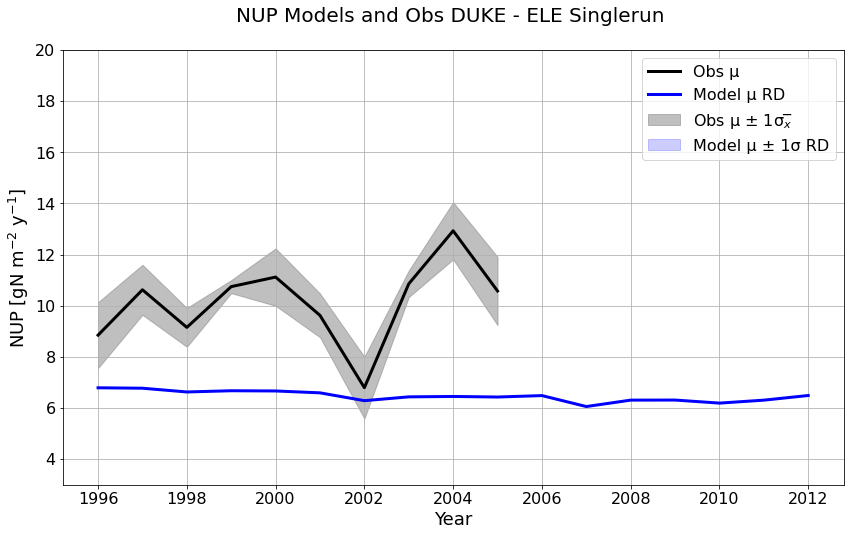

In [283]:
# Set the year as the index

# Plot the data
plt.figure(figsize=(14, 8))

# OBS

Mean_DF = dict_plot_data_obs_ax[site][co2_case]
Standard_error_DF = dict_plot_data_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NUP']
se_npp = Standard_error_DF['NUP']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
#plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df = dict_plot_data_mod[site][co2_case][fn]["NUP"]
years = df["Year"]
#df.set_index('Year', inplace=True)


for fn in fns:
    mean_model = dict_plot_data_mod[site][co2_case][fn]["NUP"]["mean"]
    std_model  = dict_plot_data_mod[site][co2_case][fn]["NUP"]["std"]
    if fn == "RD": color_fn = "blue"
    if fn == "ECA" : color_fn = "green"
    plt.plot(years, mean_model, label=f'Model μ {fn}', color=color_fn, lw=3)
    plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color=color_fn, alpha=0.2)
    #plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color=color_fn, alpha=0.2)
    

# Add labels and title
plt.xlabel('Year',fontsize=18 )
plt.ylabel(f'NUP [{NUP_units}]', fontsize=18)
plt.title(f'NUP Models and Obs {site} - {co2_case} Singlerun \n', fontsize= 20)
plt.legend(fontsize=16, loc="upper right")
plt.ylim (3, 20) 
# Show grid and the plot
plt.grid(True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Display the plot
#plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/Final/NUP_Modex_{site}_{co2_case}_SingleRun.png",bbox_inches='tight')
plt.show()


## NPP response (final)

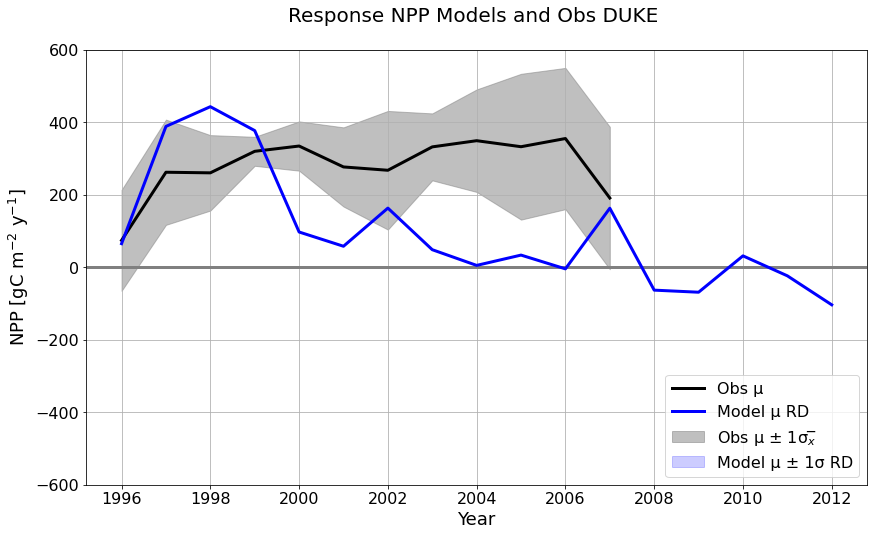

In [284]:
# Set the year as the index

# Plot the data
plt.figure(figsize=(14, 8))

# OBS

Mean_DF1 = dict_plot_data_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
Mean_DF0 = dict_plot_data_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

Mean_DF = Mean_DF1[["YEAR","NPP", "NUP"]] - Mean_DF0[["YEAR","NPP", "NUP"]]
Mean_DF["YEAR"] = Mean_DF1["YEAR"]

Standard_error_DF1 = dict_plot_data_obs_ase[site][CO2_cases[1]].reset_index(drop=True)
Standard_error_DF0 = dict_plot_data_obs_ase[site][CO2_cases[0]].reset_index(drop=True)

Standard_error_DF = ((Standard_error_DF1[["YEAR","NPP", "NUP"]])**2 + (Standard_error_DF0[["YEAR","NPP", "NUP"]])**2)**.5
Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]

# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']

plt.axhline(y=0, color='gray', linestyle='-', linewidth=3)

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
#plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df0 = dict_plot_data_mod[site][CO2_cases[0]][fn]["FATES_NPP_Minus_EXCESS_RESP"]

years = df0["Year"]
#df.set_index('Year', inplace=True)


# plot lines
#for column in list(df.columns)[:-1]:
#    plt.plot(years, df[column], linestyle='--', marker='o', label=column, color="brown", alpha=0.5)
    



for fn in fns:
    df1 = dict_plot_data_mod[site][CO2_cases[1]][fn]["FATES_NPP_Minus_EXCESS_RESP"]
    df0 = dict_plot_data_mod[site][CO2_cases[0]][fn]["FATES_NPP_Minus_EXCESS_RESP"]
    mean_model = df1["mean"] - df0["mean"]
    std_model  = (df1["std"]**2 + df0["std"]**2)**0.5
    if fn == "RD": color_fn = "blue"
    if fn == "ECA" : color_fn = "green"
    plt.plot(years, mean_model, label=f'Model μ {fn}', color=color_fn, lw=3)
    plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color=color_fn, alpha=0.2)
    #plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color=color_fn, alpha=0.2)
    

# Add labels and title
plt.xlabel('Year',fontsize=18 )
plt.ylabel(f'NPP [{NPP_units}]', fontsize=18)
plt.title(f'Response NPP Models and Obs {site} \n', fontsize= 20)

plt.ylim (-600, 600) 
# Show grid and the plot
plt.grid(True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Plot a horizontal line at y = 0
plt.legend(fontsize=16, loc="lower right")
# Display the plot
#plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/Final/NPP_Modex_{site}_Response_SingleRun.png",bbox_inches='tight')
plt.show()


## NUP response (final)

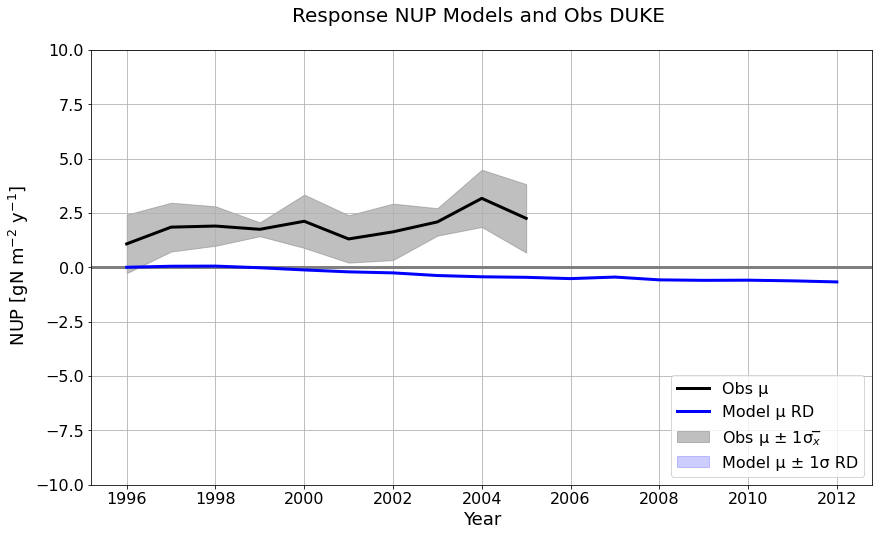

In [285]:
# Set the year as the index

# Plot the data
plt.figure(figsize=(14, 8))

# OBS

Mean_DF1 = dict_plot_data_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
Mean_DF0 = dict_plot_data_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

Mean_DF = Mean_DF1[["YEAR","NPP", "NUP"]] - Mean_DF0[["YEAR","NPP", "NUP"]]
Mean_DF["YEAR"] = Mean_DF1["YEAR"]

Standard_error_DF1 = dict_plot_data_obs_ase[site][CO2_cases[1]].reset_index(drop=True)
Standard_error_DF0 = dict_plot_data_obs_ase[site][CO2_cases[0]].reset_index(drop=True)

Standard_error_DF = ((Standard_error_DF1[["YEAR","NPP", "NUP"]])**2 + (Standard_error_DF0[["YEAR","NPP", "NUP"]])**2)**.5
Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]

# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NUP']
se_npp = Standard_error_DF['NUP']

plt.axhline(y=0, color='gray', linestyle='-', linewidth=3)

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
#plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df0 = dict_plot_data_mod[site][CO2_cases[0]][fn]["FATES_NPP_Minus_EXCESS_RESP"]

years = df0["Year"]

for fn in fns:
    df1 = dict_plot_data_mod[site][CO2_cases[1]][fn]["NUP"]
    df0 = dict_plot_data_mod[site][CO2_cases[0]][fn]["NUP"]
    mean_model = df1["mean"] - df0["mean"]
    std_model  = (df1["std"]**2 + df0["std"]**2)**0.5
    if fn == "RD": color_fn = "blue"
    if fn == "ECA" : color_fn = "green"
    plt.plot(years, mean_model, label=f'Model μ {fn}', color=color_fn, lw=3)
    plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color=color_fn, alpha=0.2)
    #plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color=color_fn, alpha=0.2)
    

# Add labels and title
plt.xlabel('Year',fontsize=18 )
plt.ylabel(f' NUP [{NUP_units}]', fontsize=18)
plt.title(f'Response NUP Models and Obs {site} \n', fontsize= 20)
plt.legend(fontsize=16, loc="lower right")
plt.ylim (-10, 10) 
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Show grid and the plot
plt.grid(True)
# Display the plot

#plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/Final/NUP_Modex_{site}_Response_SingleRun.png",bbox_inches='tight')
plt.show()
